In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/test"
test_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"

In [ ]:
import os
print(os.path.exists(train_dir))

True


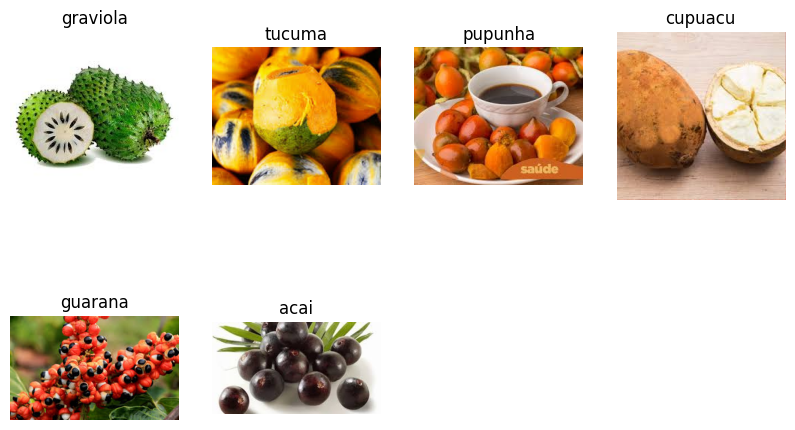

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append((img, cls))

plt.figure(figsize=(10,6))

for i, (img, label) in enumerate(images):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.show()

In [ ]:
class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
class_counts = {}

for cls in class_names:
    class_path = os.path.join(train_dir, cls)
    images = [img for img in os.listdir(class_path)
              if img.endswith(('.jpg', '.png', '.jpeg'))]
    class_counts[cls] = len(images)

print(class_counts)

{'acai': 5, 'cupuacu': 5, 'graviola': 5, 'guarana': 5, 'pupunha': 5, 'tucuma': 5}


In [ ]:
import random

selected_images = []  # Store image paths
selected_labels = []  # Store corresponding class names

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if images:  # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

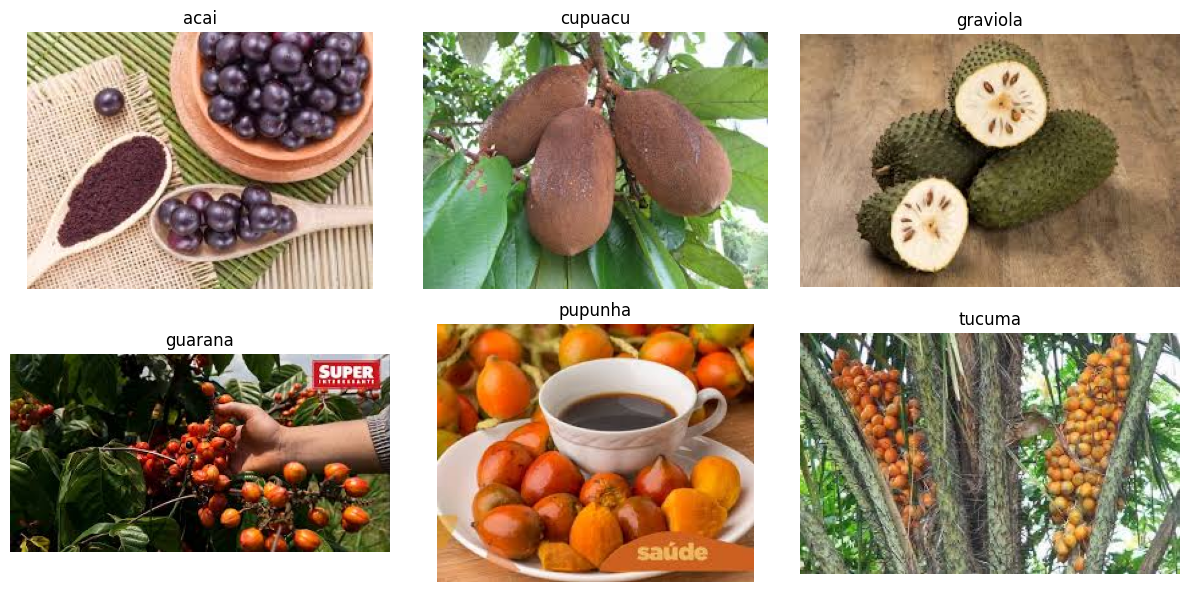

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2   # columns
rows = 2                        # fixed rows

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")  # hide empty plots

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

def remove_corrupted_images(folder):
    corrupted = []

    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except:
                print(f"Removed: {img_path}")
                os.remove(img_path)
                corrupted.append(img_path)

    if len(corrupted) == 0:
        print("No Corrupted Images Found.")

remove_corrupted_images(train_dir)
remove_corrupted_images(test_dir)

No Corrupted Images Found.
No Corrupted Images Found.


In [ ]:
# Automatically:
# Loads images
# Labels them
# Splits into train + validation

# You don’t need manual arrays anymore
from tensorflow import keras

image_size = (224, 224)   # important for CNN
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 30 files belonging to 6 classes.
Using 24 files for training.
Using 6 files for validation.


In [ ]:
# from tensorflow.keras import layers, models

# model = models.Sequential([

#     # Data Augmentation (NEW)
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.1),

#     # Rescaling
#     layers.Rescaling(1./255),

#     # BLOCK 1
#     layers.Conv2D(32, (3,3), padding='same', activation=None, input_shape=(128,128,3)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(),
#     layers.Dropout(0.25),

#     # BLOCK 2
#     layers.Conv2D(64, (3,3), padding='same', activation=None),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(),
#     layers.Dropout(0.25),

#     # BLOCK 3
#     layers.Conv2D(128, (3,3), padding='same', activation=None),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(),
#     layers.Dropout(0.25),

#     # CLASSIFIER
#     layers.Flatten(),

#     layers.Dense(256, activation=None),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.Dropout(0.5),

#     layers.Dense(num_classes, activation='softmax')
# ])

# 🔹 Transfer Learning using VGG16
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# Load pretrained VGG16 (without top classification layer)
base_model = VGG16(
    weights='imagenet',          # use pretrained ImageNet weights
    include_top=False,           # remove original classifier
    # input_shape=(128, 128, 3)    # match your dataset size
    input_shape=(224,224,3)
)

# Freeze most layers, unfreeze last few
for layer in base_model.layers[:-4]:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

# 🔹 Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)        # reduce feature maps
x = Dense(128, activation='relu')(x)   # learn task-specific features
outputs = Dense(num_classes, activation='softmax')(x)  # final output

# Create final model
model = Model(inputs=base_model.input, outputs=outputs)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

# early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=25,
#     callbacks=[checkpoint, early_stop]
# )

# Save best model
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True
)

# Stop early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.2083 - loss: 26.6346 - val_accuracy: 0.1667 - val_loss: 14.3336
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - accuracy: 0.2917 - loss: 8.4317 - val_accuracy: 0.0000e+00 - val_loss: 130.4202
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 0.2083 - loss: 125.8254 - val_accuracy: 0.1667 - val_loss: 8.9508
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step - accuracy: 0.2917 - loss: 7.1123 - val_accuracy: 0.1667 - val_loss: 6.4601
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.1667 - loss: 4.3705 - val_accuracy: 0.1667 - val_loss: 1.7635
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.1667 - loss: 1.7909 - val_accuracy: 0.0000e+00 - val_loss: 1.8950
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.2083 - loss: 1.7664 - val_accuracy: 0.1667 - val_loss: 2.0240
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.2083 - loss: 1.7253 - val_accuracy: 0.0000e+00 -

In [ ]:
# Evaluate on validation set (since no test_ds)
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1667 - loss: 1.7635
Validation Accuracy: 0.1666666716337204


In [ ]:
model.save("model.keras")

from tensorflow.keras.models import load_model
loaded_model = load_model("model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),   # force all classes
    target_names=class_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       0.17      1.00      0.29         1
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.17         6
   macro avg       0.03      0.17      0.05         6
weighted avg       0.03      0.17      0.05         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

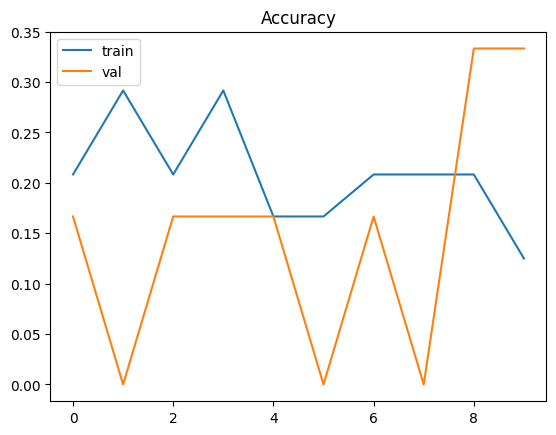

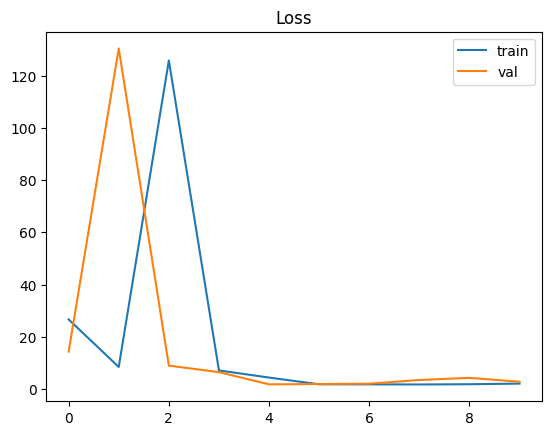

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()